In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:


# --- 1. Data Loading and Preparation ---
# Reference: Chapter 2, "Get the Data"

# Load the newly filtered training data
try:
    df_train = pd.read_csv(r"C:\Users\Erik\OneDrive - ITU\Escritorio\3 semester\Machine learning\Project\Machine-Learning-Tryg-Project\Data\claims_train_with_freq_filtered.csv")
    df_test = pd.read_csv(r"C:\Users\Erik\OneDrive - ITU\Escritorio\3 semester\Machine learning\Project\Machine-Learning-Tryg-Project\Data\claims_test_with_freq_filtered.csv")
except FileNotFoundError:
    print("Filtered data files not found. Please ensure you have run the data cleaning notebook first.")
    exit()

# Separate features (X) and the target variable (y)
X_train = df_train.drop("ClaimFrequency", axis=1)
y_train = df_train["ClaimFrequency"]

X_test = df_test.drop("ClaimFrequency", axis=1)
y_test = df_test["ClaimFrequency"]

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector

In [5]:


# --- 2. Building a Comprehensive Preprocessing Pipeline ---
# Reference: Chapter 2, "Transformation Pipelines"



# Create a pipeline for numerical features: impute missing values then scale
# The imputer fills missing values with the median of the column
# The scaler standardizes features to have zero mean and unit variance
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create a pipeline for categorical features: impute and then one-hot encode
# handle_unknown='ignore' ensures the model doesn't fail if it sees a new category in the test set
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Use a ColumnTransformer to apply the correct pipeline to each column type
# make_column_selector automatically finds columns of a specific dtype (e.g., numbers or objects)
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    ('categorical', categorical_pipeline, make_column_selector(dtype_include=object))
])


In [6]:


# --- 3. Creating the Full Model Pipeline with Hyperparameter Tuning ---
# Reference: Chapter 2, "Grid Search" and Chapter 6, "Regularization Hyperparameters"

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Chain the preprocessor and the DecisionTreeRegressor into a single pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Define a grid of hyperparameters to search through.
# These parameters help prevent the tree from overfitting.
param_grid = {
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_leaf': [10, 20, 50],
    'regressor__min_samples_split': [20, 50, 100]
}

# Use GridSearchCV to find the best combination of parameters using 5-fold cross-validation
# We use 'neg_mean_squared_error' as scikit-learn maximizes scores (higher is better)
grid_search = GridSearchCV(full_pipeline, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1) # Use all available CPU cores

print("Starting hyperparameter tuning with GridSearchCV...")
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding cross-validation score
print(f"Best parameters found: {grid_search.best_params_}")
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

Starting hyperparameter tuning with GridSearchCV...
Best parameters found: {'regressor__max_depth': 15, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 20}
Best cross-validation RMSE: 0.9197


In [ ]:
# --- 4. Evaluating the Final Model on the Test Set with Multiple Metrics ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

print("\nEvaluating the best model on the test set...")

# The best model is the one found by GridSearchCV
final_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = final_model.predict(X_test)

# --- Calculate and print the evaluation metrics ---

# Root Mean Squared Error (RMSE): Penalizes large errors more.
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final Test Set RMSE: {final_rmse:.4f}")

# Mean Absolute Error (MAE): Gives a direct sense of the average error magnitude.
final_mae = mean_absolute_error(y_test, y_pred)
print(f"Final Test Set MAE: {final_mae:.4f}")

# R-Squared (R²): Indicates the proportion of variance in the target explained by the model.
final_r2 = r2_score(y_test, y_pred)
print(f"Final Test Set R-squared: {final_r2:.4f}")




Evaluating the best model on the test set...
Final Test Set RMSE: 1.5401
Final Test Set MAE: 0.0148
Final Test Set R-squared: 0.9126
MAPE cannot be calculated as the test set contains zero values for ClaimFrequency.



Displaying feature importances...


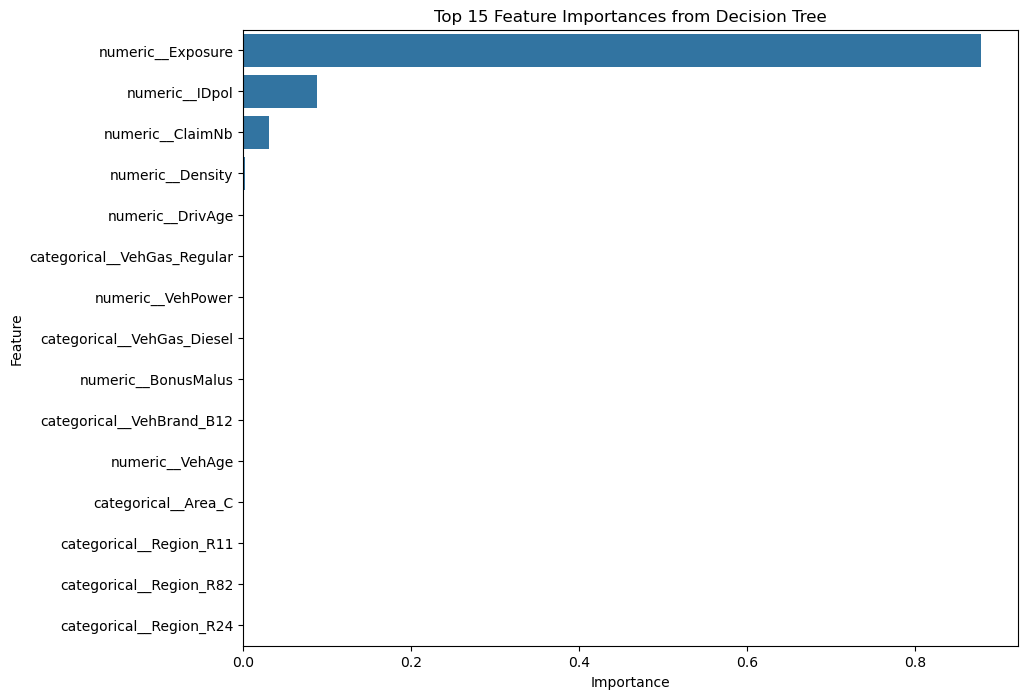


Visualizing the structure of the decision tree (top levels)...


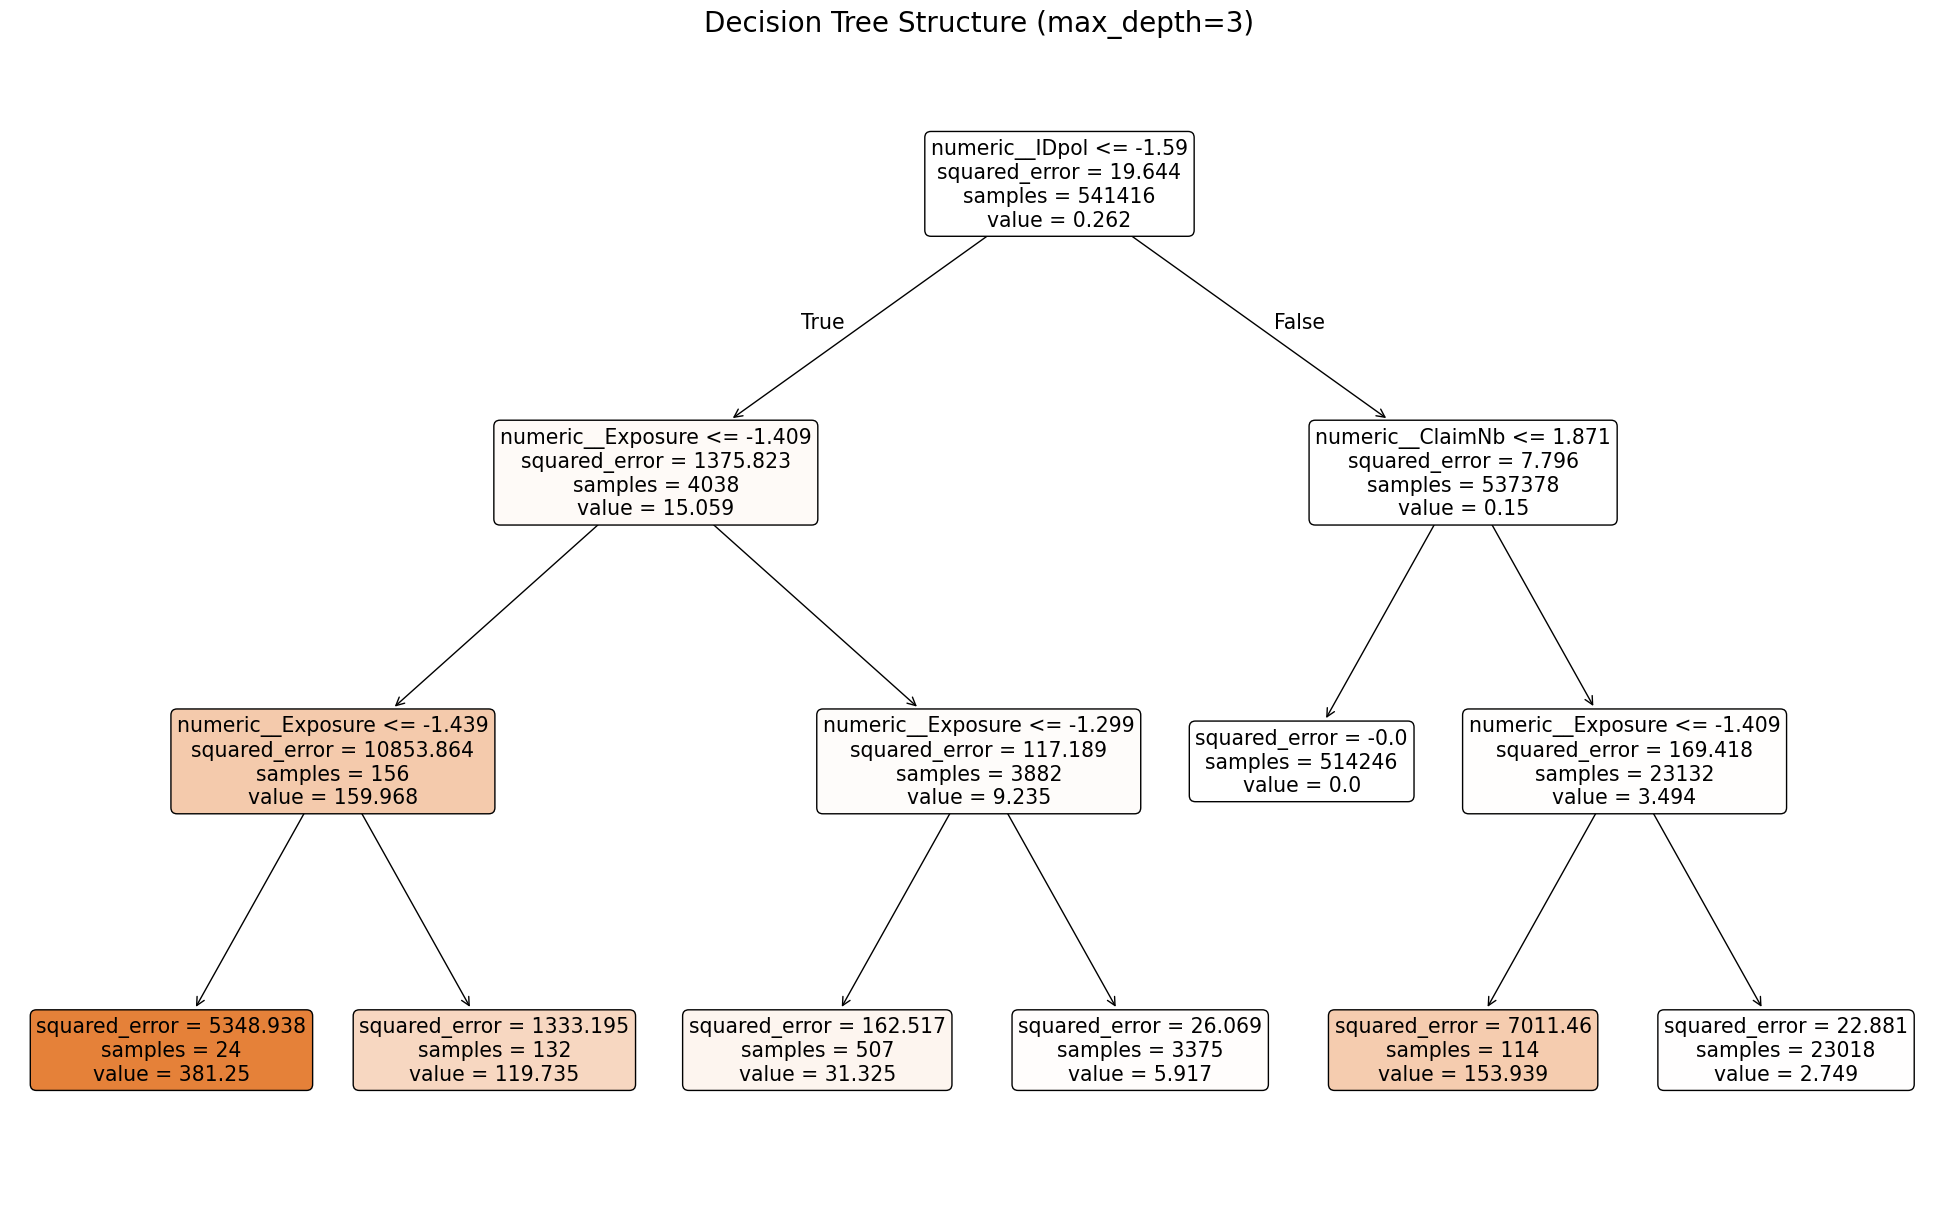

In [8]:
# --- 5. Visualizing Feature Importance ---
# Reference: Chapter 7, "Feature Importance"

print("\nDisplaying feature importances...")
# Get the feature names from the preprocessor step
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Get the importances from the trained regressor
importances = final_model.named_steps['regressor'].feature_importances_

# Create a pandas Series for easy plotting
feature_importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance_series.head(15), y=feature_importance_series.head(15).index)
plt.title("Top 15 Feature Importances from Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# --- 6. Visualizing the Decision Tree Structure ---
# Reference: Chapter 6, "Training and Visualizing a Decision Tree"
from sklearn.tree import plot_tree

print("\nVisualizing the structure of the decision tree (top levels)...")
# We will create a simplified model with a shallow depth for readability
simplified_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=3, random_state=42)) # max_depth=3 for a readable plot
])
simplified_pipeline.fit(X_train, y_train)

# Get feature names for the plot
feature_names_for_plot = simplified_pipeline.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(25, 15))
plot_tree(
    simplified_pipeline.named_steps['regressor'],
    feature_names=feature_names_for_plot,
    filled=True,
    rounded=True,
    precision=3 # Show values with 3 decimal places
)
plt.title("Decision Tree Structure (max_depth=3)", fontsize=20)
plt.show()